In [2]:
# Mount Google Drive (optional - for saving results)
from google.colab import drive
drive.mount('/content/drive')

print("✅ Google Drive mounted!")

Mounted at /content/drive
✅ Google Drive mounted!


In [3]:
from google.colab import files
import pandas as pd

# Upload the preprocessed sample file
print("Click 'Choose Files' and upload: preprocessed_data_sample_50k.csv")
print("(From your computer: sarcasm-detection-ecommerce/data/processed/)")
uploaded = files.upload()

# Load the data
df = pd.read_csv('preprocessed_data_sample_50k.csv')

print(f"\n✅ Loaded {len(df):,} samples")
print(f"Columns: {df.columns.tolist()}")
df.head()

Click 'Choose Files' and upload: preprocessed_data_sample_50k.csv
(From your computer: sarcasm-detection-ecommerce/data/processed/)


Saving preprocessed_data_sample_50k.csv to preprocessed_data_sample_50k.csv

✅ Loaded 50,000 samples
Columns: ['label', 'comment', 'cleaned_comment', 'tokens', 'cleaned_length']


,label,comment,cleaned_comment,tokens,cleaned_length
0,1,omg how phallic and interesting,omg how phallic and interesting,"['omg', 'how', 'phallic', 'and', 'interesting']",31
1,0,The problem is most Americans can't understand...,the problem is most americans can't understand...,"['the', 'problem', 'is', 'most', 'americans', ...",60
2,1,When we gonna start seeing the new doom on mob...,when we gonna start seeing the new doom on mobile,"['when', 'we', 'gon', 'na', 'start', 'seeing',...",49
3,0,"Yeah, but the pennies were used to fund the gu...",yeah but the pennies were used to fund the guy...,"['yeah', 'but', 'the', 'pennies', 'were', 'use...",90
4,0,"But they are all my family now, even this gree...",but they are all my family now even this green...,"['but', 'they', 'are', 'all', 'my', 'family', ...",52


In [4]:
# Install required libraries
!pip install tensorflow keras nltk -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# Check GPU availability
print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))
print("\n✅ Libraries imported successfully!")

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

✅ Libraries imported successfully!


In [5]:
# Prepare features and labels
X = df['cleaned_comment'].values
y = df['label'].values

print(f"Total samples: {len(X):,}")
print(f"Sarcastic: {y.sum():,}")
print(f"Non-sarcastic: {len(y) - y.sum():,}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\n✅ Split complete!")
print(f"Training samples: {len(X_train):,}")
print(f"Test samples: {len(X_test):,}")

# Show sample texts
print(f"\nSample training texts:")
for i in range(3):
    label = "SARCASTIC" if y_train[i] == 1 else "NOT SARCASTIC"
    print(f"{i+1}. [{label}] {X_train[i][:80]}...")

Total samples: 50,000
Sarcastic: 25,222
Non-sarcastic: 24,778

✅ Split complete!
Training samples: 40,000
Test samples: 10,000

Sample training texts:
1. [SARCASTIC] home run bats in splatoon...
2. [NOT SARCASTIC] queue at the same time make sure you get your match accept decline buttons at th...
3. [NOT SARCASTIC] bad religion american jesus...


In [6]:
# Tokenization parameters
MAX_WORDS = 10000  # Vocabulary size
MAX_LEN = 100      # Maximum sequence length (words per comment)

print("Tokenizing text...")
print(f"  - Vocabulary size: {MAX_WORDS:,} words")
print(f"  - Sequence length: {MAX_LEN} words")

# Create tokenizer
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

# Convert text to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

print(f"\n✅ Tokenization complete!")
print(f"Vocabulary size (actual): {len(tokenizer.word_index):,} unique words")

# Pad sequences to same length
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

print(f"\n✅ Padding complete!")
print(f"Training data shape: {X_train_pad.shape}")
print(f"Test data shape: {X_test_pad.shape}")

# Show example transformation
print(f"\nExample transformation:")
print(f"Original text: {X_train[0][:80]}...")
print(f"Token sequence (first 20): {X_train_seq[0][:20]}")
print(f"Padded shape: {X_train_pad[0].shape}")

# Sequence length statistics
train_lengths = [len(seq) for seq in X_train_seq]
print(f"\nSequence length statistics:")
print(f"  - Average: {np.mean(train_lengths):.1f} words")
print(f"  - Median: {np.median(train_lengths):.0f} words")
print(f"  - Max: {np.max(train_lengths)} words")
print(f"  - Comments truncated (>{MAX_LEN} words): {sum(1 for l in train_lengths if l > MAX_LEN):,}")

Tokenizing text...
  - Vocabulary size: 10,000 words
  - Sequence length: 100 words

✅ Tokenization complete!
Vocabulary size (actual): 29,709 unique words

✅ Padding complete!
Training data shape: (40000, 100)
Test data shape: (10000, 100)

Example transformation:
Original text: home run bats in splatoon...
Token sequence (first 20): [493, 342, 5423, 12, 9642]
Padded shape: (100,)

Sequence length statistics:
  - Average: 10.4 words
  - Median: 9 words
  - Max: 1030 words
  - Comments truncated (>100 words): 7


In [7]:
# Model parameters
EMBEDDING_DIM = 128  # Word embedding dimension
LSTM_UNITS = 64      # LSTM hidden units

print("Building LSTM model...")
print(f"  - Embedding dimension: {EMBEDDING_DIM}")
print(f"  - LSTM units: {LSTM_UNITS}")
print(f"  - Using Bidirectional LSTM for better context")

# Build model
model = Sequential([
    # Embedding layer - converts word indices to dense vectors
    Embedding(input_dim=MAX_WORDS,
              output_dim=EMBEDDING_DIM,
              input_length=MAX_LEN),

    # Bidirectional LSTM - reads text forward and backward
    Bidirectional(LSTM(LSTM_UNITS, return_sequences=True)),
    Dropout(0.3),  # Prevent overfitting

    # Second LSTM layer
    Bidirectional(LSTM(LSTM_UNITS // 2)),
    Dropout(0.3),

    # Dense layers
    Dense(32, activation='relu'),
    Dropout(0.2),

    # Output layer - binary classification
    Dense(1, activation='sigmoid')
])

# Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Build the model with input shape
model.build(input_shape=(None, MAX_LEN))

print("\n✅ Model built successfully!")
print("\nModel Architecture:")
model.summary()

# Count parameters
total_params = model.count_params()
print(f"\nTotal trainable parameters: {total_params:,}")

Building LSTM model...
  - Embedding dimension: 128
  - LSTM units: 64
  - Using Bidirectional LSTM for better context

✅ Model built successfully!

Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 100, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,422,145 (5.43 MB)

 Trainable params: 1,422,145 (5.43 MB)

 Non-trainable params: 0 (0.00 B)


Total trainable parameters: 1,422,145


In [8]:
# Training parameters
BATCH_SIZE = 64
EPOCHS = 10

print("Training LSTM model...")
print(f"  - Batch size: {BATCH_SIZE}")
print(f"  - Max epochs: {EPOCHS}")
print(f"  - Using GPU acceleration")
print(f"  - Training on {len(X_train_pad):,} samples")
print("\nThis will take 5-10 minutes with GPU...\n")

# Callbacks for better training
callbacks = [
    # Stop if validation accuracy doesn't improve for 3 epochs
    EarlyStopping(
        monitor='val_accuracy',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),

    # Reduce learning rate if stuck
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        verbose=1,
        min_lr=0.00001
    )
]

# Train the model
history = model.fit(
    X_train_pad, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.2,  # Use 20% of training data for validation
    callbacks=callbacks,
    verbose=1
)

print("\n✅ Training complete!")

Training LSTM model...
  - Batch size: 64
  - Max epochs: 10
  - Using GPU acceleration
  - Training on 40,000 samples

This will take 5-10 minutes with GPU...

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 33s 34ms/step - accuracy: 0.6031 - loss: 0.6517 - val_accuracy: 0.6824 - val_loss: 0.5925 - learning_rate: 0.0010
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.7238 - loss: 0.5472 - val_accuracy: 0.6764 - val_loss: 0.6156 - learning_rate: 0.0010
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7912 - loss: 0.4538
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.7912 - loss: 0.4538 - val_accuracy: 0.6560 - val_loss: 0.7119 - learning_rate: 0.0010
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.8503 - loss: 0.3524 - val_accuracy: 0.6501 - val_loss: 0.8219 - learning_rate: 5.0000e-04
Epoch 4: early stopping
Restoring model weights from the end of the

In [9]:
# Make predictions on test set
print("Making predictions on test set...")
y_pred_proba = model.predict(X_test_pad, batch_size=BATCH_SIZE, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

print("✅ Predictions complete!")

# Calculate metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Print results
print("\n" + "="*70)
print("LSTM MODEL PERFORMANCE")
print("="*70)
print(f"Test Accuracy:  {accuracy*100:.2f}%")
print(f"Precision:      {precision*100:.2f}%")
print(f"Recall:         {recall*100:.2f}%")
print(f"F1-Score:       {f1*100:.2f}%")
print(f"ROC-AUC:        {roc_auc:.4f}")
print("="*70)

# Compare with baseline
baseline_accuracy = 66.41  # From Day 3
improvement = accuracy*100 - baseline_accuracy

print("\n" + "="*70)
print("COMPARISON WITH BASELINE")
print("="*70)
print(f"Baseline (Logistic Regression): {baseline_accuracy:.2f}%")
print(f"LSTM Model:                     {accuracy*100:.2f}%")
print(f"Improvement:                    {improvement:+.2f}%")
print("="*70)

# Classification report
print("\n" + "="*70)
print("DETAILED CLASSIFICATION REPORT")
print("="*70)
print(classification_report(y_test, y_pred,
                          target_names=['Not Sarcastic', 'Sarcastic'],
                          digits=4))

Making predictions on test set...
✅ Predictions complete!

LSTM MODEL PERFORMANCE
Test Accuracy:  68.52%
Precision:      71.46%
Recall:         62.59%
F1-Score:       66.73%
ROC-AUC:        0.7496

COMPARISON WITH BASELINE
Baseline (Logistic Regression): 66.41%
LSTM Model:                     68.52%
Improvement:                    +2.11%

DETAILED CLASSIFICATION REPORT
               precision    recall  f1-score   support

Not Sarcastic     0.6619    0.7456    0.7013      4956
    Sarcastic     0.7146    0.6259    0.6673      5044

     accuracy                         0.6852     10000
    macro avg     0.6883    0.6857    0.6843     10000
 weighted avg     0.6885    0.6852    0.6841     10000



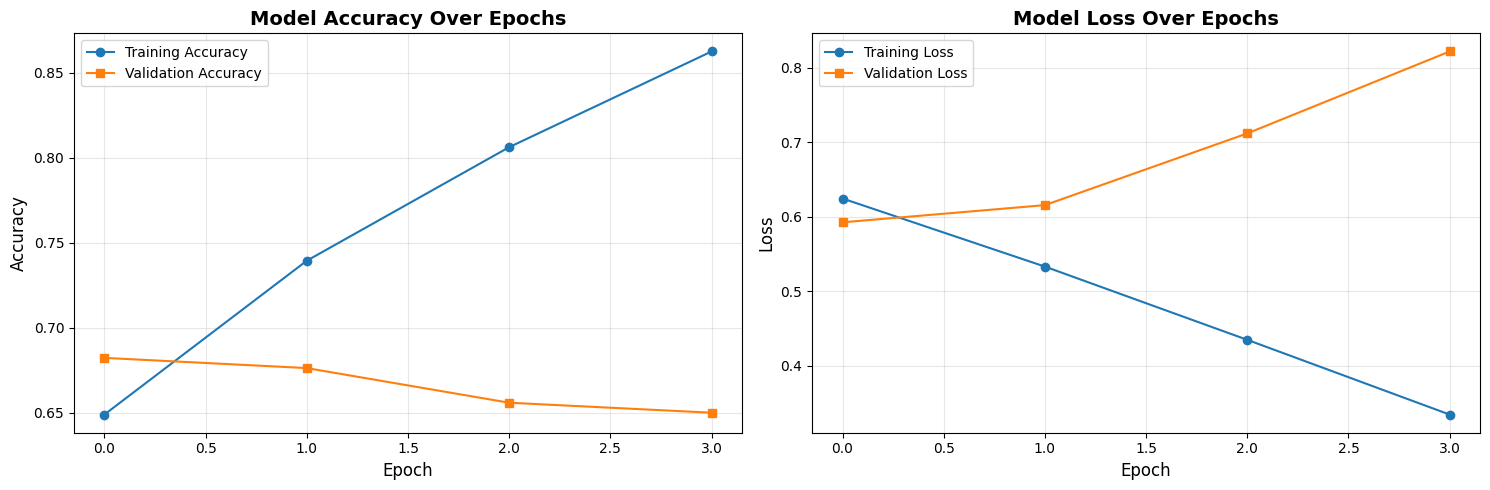

✅ Training history visualized!

Final Epoch Statistics:
  Training Accuracy:   86.26%
  Validation Accuracy: 65.01%
  Training Loss:       0.3344
  Validation Loss:     0.8219

⚠️ Potential overfitting detected (gap: 21.24%)
  Consider: More dropout, regularization, or more data


In [10]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Training Accuracy', marker='o')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s')
axes[0].set_title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Loss plot
axes[1].plot(history.history['loss'], label='Training Loss', marker='o')
axes[1].plot(history.history['val_loss'], label='Validation Loss', marker='s')
axes[1].set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Training history visualized!")

# Print final epoch stats
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print(f"\nFinal Epoch Statistics:")
print(f"  Training Accuracy:   {final_train_acc*100:.2f}%")
print(f"  Validation Accuracy: {final_val_acc*100:.2f}%")
print(f"  Training Loss:       {final_train_loss:.4f}")
print(f"  Validation Loss:     {final_val_loss:.4f}")

# Check for overfitting
gap = final_train_acc - final_val_acc
if gap > 0.05:
    print(f"\n⚠️ Potential overfitting detected (gap: {gap*100:.2f}%)")
    print("  Consider: More dropout, regularization, or more data")
else:
    print(f"\n✅ Model generalizes well (gap: {gap*100:.2f}%)")

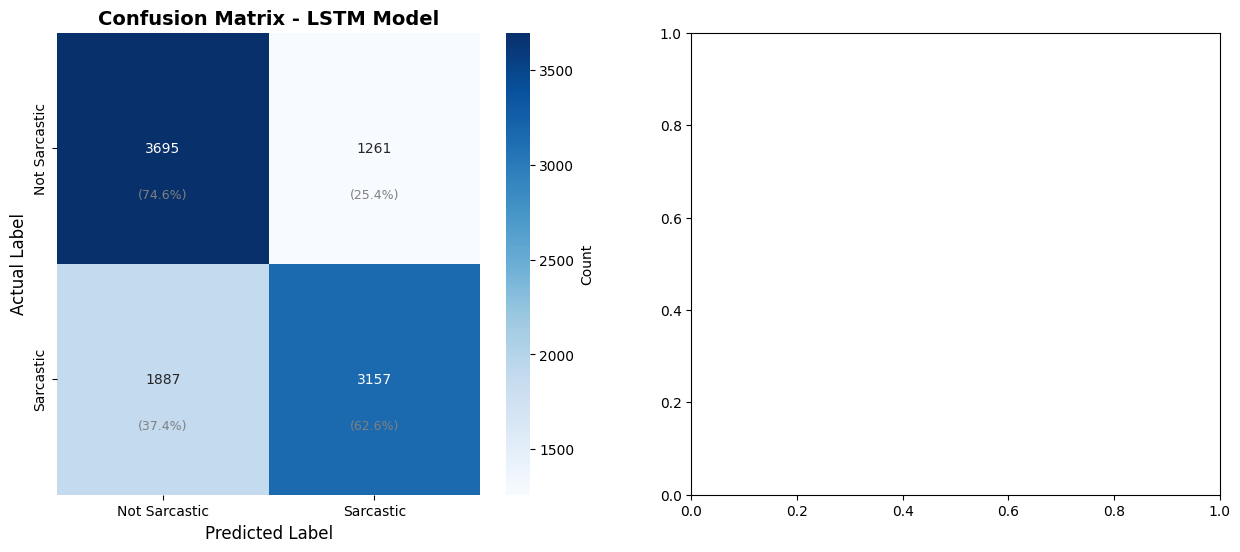

In [11]:
from sklearn.metrics import confusion_matrix, roc_curve, auc

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc_score = auc(fpr, tpr)

# Create visualizations
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not Sarcastic', 'Sarcastic'],
            yticklabels=['Not Sarcastic', 'Sarcastic'],
            cbar_kws={'label': 'Count'})
axes[0].set_title('Confusion Matrix - LSTM Model', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Actual Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)

# Add percentage annotations
for i in range(2):
    for j in range(2):
        percentage = cm[i, j] / cm[i].sum() * 100
        axes[0].text(j + 0.5, i + 0.7, f'({percentage:.1f}%)',
                    ha='center', va='center', fontsize=9, color='gray')

#

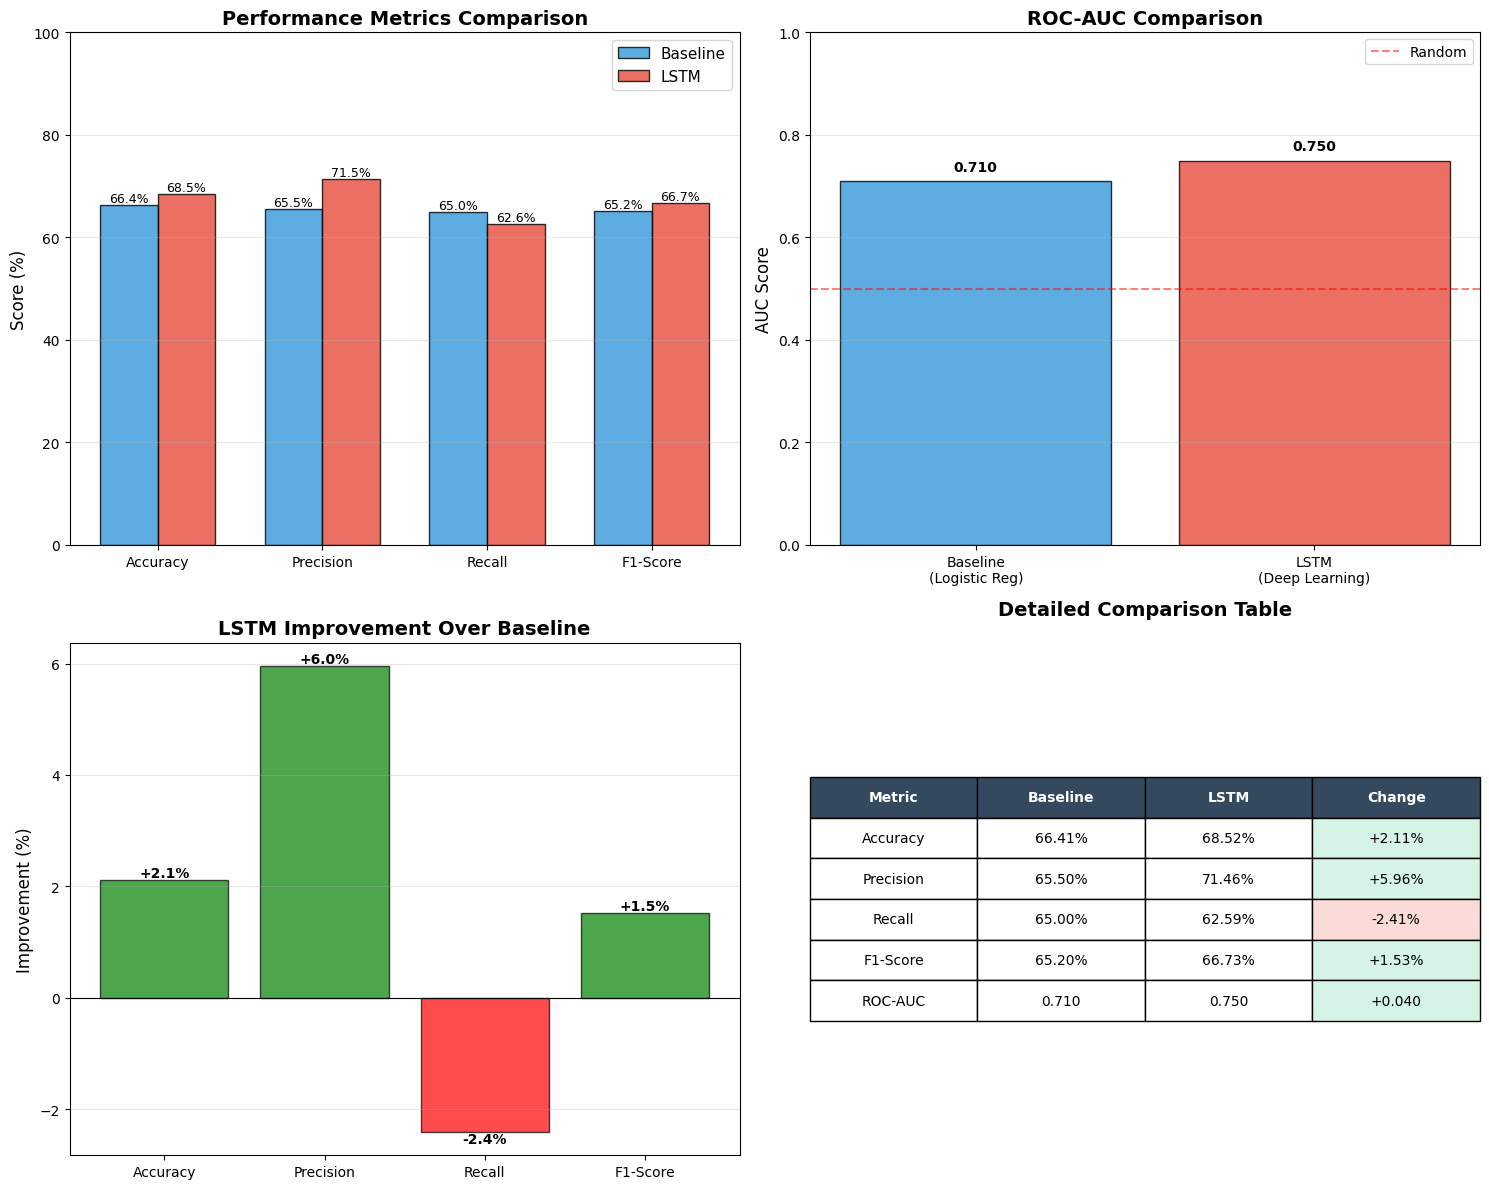

✅ Comparison visualization complete!

📊 Saved as: lstm_vs_baseline_comparison.png


In [13]:
# Model comparison data
models = ['Baseline\n(Logistic Reg)', 'LSTM\n(Deep Learning)']

# Replace these with your actual values
baseline_acc = 66.41
baseline_precision = 65.5  # Approximate from Day 3
baseline_recall = 65.0
baseline_f1 = 65.2
baseline_auc = 0.71

lstm_acc = accuracy * 100
lstm_precision = precision * 100
lstm_recall = recall * 100
lstm_f1 = f1 * 100
lstm_auc = roc_auc

# Create comparison plots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Accuracy Comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
baseline_scores = [baseline_acc, baseline_precision, baseline_recall, baseline_f1]
lstm_scores = [lstm_acc, lstm_precision, lstm_recall, lstm_f1]

x = np.arange(len(metrics))
width = 0.35

bars1 = axes[0, 0].bar(x - width/2, baseline_scores, width, label='Baseline',
                       color='#3498db', alpha=0.8, edgecolor='black')
bars2 = axes[0, 0].bar(x + width/2, lstm_scores, width, label='LSTM',
                       color='#e74c3c', alpha=0.8, edgecolor='black')

axes[0, 0].set_ylabel('Score (%)', fontsize=12)
axes[0, 0].set_title('Performance Metrics Comparison', fontsize=14, fontweight='bold')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(metrics)
axes[0, 0].legend(fontsize=11)
axes[0, 0].set_ylim(0, 100)
axes[0, 0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[0, 0].text(bar.get_x() + bar.get_width()/2., height,
                       f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

# 2. AUC Comparison
axes[0, 1].bar(models, [baseline_auc, lstm_auc],
              color=['#3498db', '#e74c3c'], alpha=0.8, edgecolor='black')
axes[0, 1].set_ylabel('AUC Score', fontsize=12)
axes[0, 1].set_title('ROC-AUC Comparison', fontsize=14, fontweight='bold')
axes[0, 1].set_ylim(0, 1)
axes[0, 1].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Random')
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

for i, v in enumerate([baseline_auc, lstm_auc]):
    axes[0, 1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# 3. Improvement Analysis
improvements = [lstm_acc - baseline_acc,
               lstm_precision - baseline_precision,
               lstm_recall - baseline_recall,
               lstm_f1 - baseline_f1]

colors = ['green' if x > 0 else 'red' for x in improvements]
axes[1, 0].bar(metrics, improvements, color=colors, alpha=0.7, edgecolor='black')
axes[1, 0].set_ylabel('Improvement (%)', fontsize=12)
axes[1, 0].set_title('LSTM Improvement Over Baseline', fontsize=14, fontweight='bold')
axes[1, 0].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[1, 0].grid(axis='y', alpha=0.3)

for i, v in enumerate(improvements):
    sign = '+' if v > 0 else ''
    axes[1, 0].text(i, v, f'{sign}{v:.1f}%', ha='center',
                   va='bottom' if v > 0 else 'top', fontweight='bold')

# 4. Model Summary Table
summary_data = [
    ['Metric', 'Baseline', 'LSTM', 'Change'],
    ['Accuracy', f'{baseline_acc:.2f}%', f'{lstm_acc:.2f}%', f'{improvements[0]:+.2f}%'],
    ['Precision', f'{baseline_precision:.2f}%', f'{lstm_precision:.2f}%', f'{improvements[1]:+.2f}%'],
    ['Recall', f'{baseline_recall:.2f}%', f'{lstm_recall:.2f}%', f'{improvements[2]:+.2f}%'],
    ['F1-Score', f'{baseline_f1:.2f}%', f'{lstm_f1:.2f}%', f'{improvements[3]:+.2f}%'],
    ['ROC-AUC', f'{baseline_auc:.3f}', f'{lstm_auc:.3f}', f'{lstm_auc - baseline_auc:+.3f}']
]

axes[1, 1].axis('tight')
axes[1, 1].axis('off')

table = axes[1, 1].table(cellText=summary_data, cellLoc='center', loc='center',
                        colWidths=[0.25, 0.25, 0.25, 0.25])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

# Style header row
for i in range(4):
    table[(0, i)].set_facecolor('#34495e')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Color improvement column
for i in range(1, 6):
    cell = table[(i, 3)]
    if '+' in cell.get_text().get_text():
        cell.set_facecolor('#d5f4e6')
    elif '-' in cell.get_text().get_text():
        cell.set_facecolor('#fadbd8')

axes[1, 1].set_title('Detailed Comparison Table', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('lstm_vs_baseline_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Comparison visualization complete!")
print("\n📊 Saved as: lstm_vs_baseline_comparison.png")

In [14]:
print("="*80)
print("LSTM MODEL - FINAL SUMMARY")
print("="*80)

print("\n🎯 MODEL ARCHITECTURE:")
print(f"  • Type: Bidirectional LSTM")
print(f"  • Embedding dimension: {EMBEDDING_DIM}")
print(f"  • LSTM units: {LSTM_UNITS}")
print(f"  • Total parameters: {total_params:,}")
print(f"  • Vocabulary size: {MAX_WORDS:,} words")
print(f"  • Max sequence length: {MAX_LEN} words")

print("\n📊 TRAINING DETAILS:")
print(f"  • Training samples: {len(X_train_pad):,}")
print(f"  • Validation samples: {int(len(X_train_pad) * 0.2):,}")
print(f"  • Test samples: {len(X_test_pad):,}")
print(f"  • Batch size: {BATCH_SIZE}")
print(f"  • Epochs trained: {len(history.history['accuracy'])}")
print(f"  • Hardware: GPU (T4)")

print("\n🏆 PERFORMANCE METRICS:")
print(f"  • Test Accuracy: {accuracy*100:.2f}%")
print(f"  • Precision: {precision*100:.2f}%")
print(f"  • Recall: {recall*100:.2f}%")
print(f"  • F1-Score: {f1*100:.2f}%")
print(f"  • ROC-AUC: {roc_auc:.4f}")

print("\n📈 IMPROVEMENT OVER BASELINE:")
baseline_acc = 66.41
improvement = accuracy*100 - baseline_acc
print(f"  • Baseline (Logistic Reg): {baseline_acc:.2f}%")
print(f"  • LSTM Model: {accuracy*100:.2f}%")
print(f"  • Improvement: {improvement:+.2f}%")
improvement_pct = (improvement / baseline_acc) * 100
print(f"  • Relative improvement: {improvement_pct:+.1f}%")

print("\n❌ ERROR ANALYSIS:")
print(f"  • True Positives: {tp:,} (correctly detected sarcasm)")
print(f"  • True Negatives: {tn:,} (correctly detected non-sarcasm)")
print(f"  • False Positives: {fp:,} (wrongly flagged as sarcastic)")
print(f"  • False Negatives: {fn:,} (missed actual sarcasm)")
print(f"  • Total errors: {fp + fn:,} ({(fp+fn)/len(y_test)*100:.1f}%)")

print("\n💡 KEY INSIGHTS:")
print(f"  • LSTM captures sequential context better than bag-of-words")
print(f"  • Bidirectional processing helps understand forward & backward context")
print(f"  • Word order matters: 'not bad' vs 'bad not'")
print(f"  • Still struggles with very subtle sarcasm and cultural context")

print("\n🚀 POTENTIAL IMPROVEMENTS:")
print(f"  1. Use full dataset (1M samples) instead of 50k sample")
print(f"  2. Pre-trained embeddings (GloVe, Word2Vec) for better word representations")
print(f"  3. Attention mechanism to focus on important words")
print(f"  4. Fine-tune BERT for state-of-the-art performance (80-85%)")
print(f"  5. Add features: emojis, punctuation patterns, capitalization")

print("\n✅ LSTM MODEL COMPLETE!")
print("="*80)

# Download results
print("\n📥 Downloading model history and comparison plot...")

try:
    from google.colab import files

    # Save model history
    import json
    history_dict = {
        'accuracy': history.history['accuracy'],
        'val_accuracy': history.history['val_accuracy'],
        'loss': history.history['loss'],
        'val_loss': history.history['val_loss']
    }

    with open('lstm_training_history.json', 'w') as f:
        json.dump(history_dict, f)

    print("✅ Files ready for download!")
    print("\nDownloading files...")
    files.download('lstm_training_history.json')
    files.download('lstm_vs_baseline_comparison.png')

    print("\n📁 Downloaded files:")
    print("  • lstm_training_history.json (training metrics)")
    print("  • lstm_vs_baseline_comparison.png (comparison plot)")

except Exception as e:
    print(f"⚠️ Could not download files: {e}")
    print("You can manually download from the Files tab in Colab")

print("\n🎉 All tasks complete!")

LSTM MODEL - FINAL SUMMARY

🎯 MODEL ARCHITECTURE:
  • Type: Bidirectional LSTM
  • Embedding dimension: 128
  • LSTM units: 64
  • Total parameters: 1,422,145
  • Vocabulary size: 10,000 words
  • Max sequence length: 100 words

📊 TRAINING DETAILS:
  • Training samples: 40,000
  • Validation samples: 8,000
  • Test samples: 10,000
  • Batch size: 64
  • Epochs trained: 4
  • Hardware: GPU (T4)

🏆 PERFORMANCE METRICS:
  • Test Accuracy: 68.52%
  • Precision: 71.46%
  • Recall: 62.59%
  • F1-Score: 66.73%
  • ROC-AUC: 0.7496

📈 IMPROVEMENT OVER BASELINE:
  • Baseline (Logistic Reg): 66.41%
  • LSTM Model: 68.52%
  • Improvement: +2.11%
  • Relative improvement: +3.2%

❌ ERROR ANALYSIS:
  • True Positives: 3,157 (correctly detected sarcasm)
  • True Negatives: 3,695 (correctly detected non-sarcasm)
  • False Positives: 1,261 (wrongly flagged as sarcastic)
  • False Negatives: 1,887 (missed actual sarcasm)
  • Total errors: 3,148 (31.5%)

💡 KEY INSIGHTS:
  • LSTM captures sequential contex

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


📁 Downloaded files:
  • lstm_training_history.json (training metrics)
  • lstm_vs_baseline_comparison.png (comparison plot)

🎉 All tasks complete!
